In [40]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder

In [41]:
df = pd.read_csv("/Users/yashwanthkumar/Desktop/Desktop/ML project/early_layoff_warning/data/master_dataset.csv")
df.head(10)

,Industry,Stage,Country,Funds_Raised,Cash_Reserves,Profit_Margin,Revenue_Growth,Laid_Off
0,Hardware,Post-IPO,United States,1200.0,9.094300e+10,0.195879,0.045113,0
1,Hardware,Post-IPO,United States,1200.0,7.682600e+10,0.258034,0.722449,0
2,Hardware,Post-IPO,United States,1200.0,6.983400e+10,0.263775,-0.196116,0
3,Hardware,Post-IPO,United States,1200.0,6.169600e+10,0.267014,-0.090976,0
4,Hardware,Post-IPO,United States,1200.0,6.263900e+10,0.246533,0.023651,0
5,Hardware,Post-IPO,United States,1200.0,6.391300e+10,0.279398,0.486864,0
6,Hardware,Post-IPO,United States,1200.0,5.151100e+10,0.257098,-0.215152,0
7,Hardware,Post-IPO,United States,1200.0,4.823100e+10,0.234357,-0.147197,0
8,Hardware,Post-IPO,United States,1200.0,4.830400e+10,0.229860,0.086633,0
9,Hardware,Post-IPO,United States,1200.0,5.135500e+10,0.256056,0.299603,0


In [42]:
# Drop columns that are not features
# - Company: just a name, not a signal
# - Date: used for alignment, not a feature
# - Date_Added: metadata
# - Source: URL, not a feature
# - List_of_Employees_Laid_Off: text, not useful here
# - Laid_Off_Count: leakage - you don't know this before a layoff
# - Laid_Off_Count_Log: same, leakage
# - Percentage: same, leakage
# - Location_HQ: too granular, Country covers this

cols_to_drop = ['Ticker','Company', 'Date', 'Laid_Off_Count', 
                'Laid_Off_Count_Log', 'Percentage']

df_model = df.drop(columns=cols_to_drop, errors='ignore')

print(df_model.shape)
print(df_model.columns.tolist())

(1301, 8)
['Industry', 'Stage', 'Country', 'Funds_Raised', 'Cash_Reserves', 'Profit_Margin', 'Revenue_Growth', 'Laid_Off']


In [43]:
df_model.isnull().sum()

Industry          0
Stage             0
Country           0
Funds_Raised      0
Cash_Reserves     0
Profit_Margin     0
Revenue_Growth    0
Laid_Off          0
dtype: int64

In [44]:
df_model["Funds_Raised"] = df_model["Funds_Raised"].fillna(0)

for col in ["Cash_Reserves", "Profit_Margin", "Revenue_Growth"]:
    median_val = df_model[col].median()

    df_model[col] = df_model[col].fillna(median_val)

df_model.isnull().sum()

Industry          0
Stage             0
Country           0
Funds_Raised      0
Cash_Reserves     0
Profit_Margin     0
Revenue_Growth    0
Laid_Off          0
dtype: int64

In [45]:
# Check unique values first
print(f"Industry unique: {df_model['Industry'].nunique()}")
print(f"Stage unique: {df_model['Stage'].nunique()}")
print(f"Country unique: {df_model['Country'].nunique()}")

Industry unique: 25
Stage unique: 2
Country unique: 1


In [46]:
X = df_model.drop(columns="Laid_Off")
y = df_model["Laid_Off"]

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2, random_state=42, stratify= y)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1040, 7)
(261, 7)
(1040,)
(261,)


In [48]:
oe = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)

X_train[["Industry", "Stage", "Country"]] = oe.fit_transform(X_train[["Industry", "Stage", "Country"]])

X_test[["Industry", "Stage", "Country"]] = oe.transform(X_test[["Industry", "Stage", "Country"]])

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

import pickle 
import json

with open("/Users/yashwanthkumar/Desktop/Desktop/ML project/early_layoff_warning/models/ordinal_encoder.pkl", "wb") as f:

    pickle.dump(oe,f)

X_train.head(10)

(1040, 7)
(261, 7)
(1040,)
(261,)


,Industry,Stage,Country,Funds_Raised,Cash_Reserves,Profit_Margin,Revenue_Growth
601,0.0,0.0,0.0,57.0,4.073800e+10,0.144660,0.160605
24,13.0,1.0,0.0,2.0,1.014400e+09,0.296124,0.045113
87,2.0,1.0,0.0,311.0,3.177630e+08,-0.803972,0.045113
558,23.0,1.0,0.0,4900.0,1.807048e+09,-0.380769,0.131540
845,0.0,1.0,0.0,857.0,3.132964e+09,-0.298253,-0.055620
77,21.0,1.0,0.0,35.0,1.098073e+09,0.133962,0.067405
317,0.0,1.0,0.0,719.0,2.152892e+09,-0.689372,1.224073
616,15.0,1.0,0.0,1.0,1.044270e+11,0.346198,0.002085
530,8.0,1.0,0.0,12.0,3.869600e+10,0.442053,-0.105953
1135,15.0,1.0,0.0,168.0,6.968410e+08,-0.072662,0.031889


In [49]:
print(X_train.isnull().sum())
print(X_test.isnull().sum())

Industry          0
Stage             0
Country           0
Funds_Raised      0
Cash_Reserves     0
Profit_Margin     0
Revenue_Growth    0
dtype: int64
Industry          0
Stage             0
Country           0
Funds_Raised      0
Cash_Reserves     0
Profit_Margin     0
Revenue_Growth    0
dtype: int64


In [50]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

In [51]:
print("\nAfter SMOTE:")
print(f"Label 0: {(y_train_balanced == 0).sum()}")
print(f"Label 1: {(y_train_balanced == 1).sum()}")
print(f"\nNew train shape: {X_train_balanced.shape}")


After SMOTE:
Label 0: 696
Label 1: 696

New train shape: (1392, 7)


classification report               precision    recall  f1-score   support

           0       0.76      0.76      0.76       175
           1       0.51      0.50      0.50        86

    accuracy                           0.67       261
   macro avg       0.63      0.63      0.63       261
weighted avg       0.67      0.67      0.67       261

ROC-AUC score  0.6300


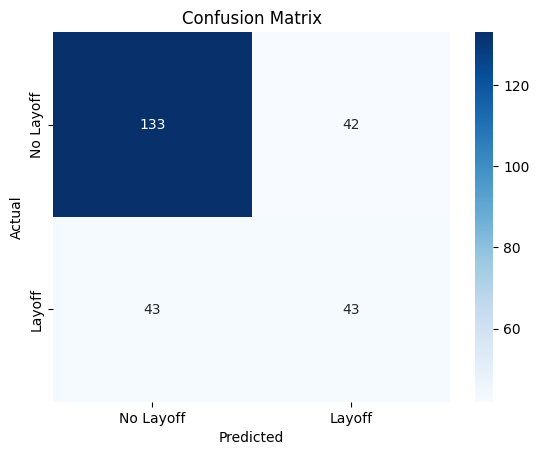

In [52]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

model = XGBClassifier()

model.fit(X_train_balanced, y_train_balanced)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

print(f"classification report {classification_report(y_test, y_pred)}")
print(f"ROC-AUC score {roc_auc_score(y_test, y_pred): .4f}")

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Layoff', 'Layoff'],
            yticklabels=['No Layoff', 'Layoff'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

classification report               precision    recall  f1-score   support

           0       0.75      0.77      0.76       175
           1       0.51      0.49      0.50        86

    accuracy                           0.68       261
   macro avg       0.63      0.63      0.63       261
weighted avg       0.67      0.68      0.68       261

ROC-AUC score  0.6299


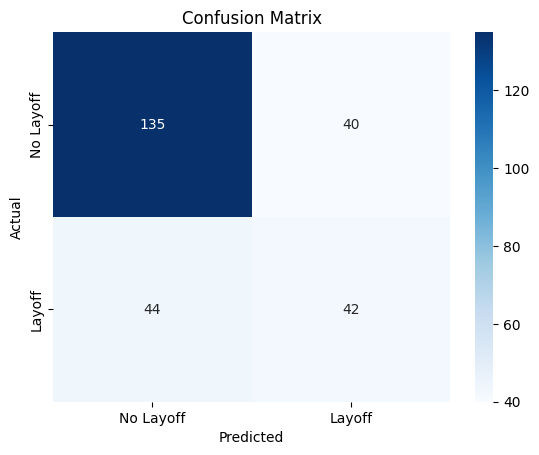

In [53]:
model_base = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)
model_base.fit(X_train_balanced, y_train_balanced)
y_pred_base = model_base.predict(X_test)
y_prob_base = model_base.predict_proba(X_test)[:, 1]

print(f"classification report {classification_report(y_test, y_pred_base)}")
print(f"ROC-AUC score {roc_auc_score(y_test, y_pred_base): .4f}")

cm = confusion_matrix(y_test, y_pred_base)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Layoff', 'Layoff'],
            yticklabels=['No Layoff', 'Layoff'])
plt.title('Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


In [54]:
scale = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nscale_pos_weight value: {scale:.2f}")

model_scaled = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)
model_scaled.fit(X_train, y_train)  # no SMOTE here, scale_pos_weight handles it
y_pred_scaled = model_scaled.predict(X_test)
y_prob_scaled = model_scaled.predict_proba(X_test)[:, 1]

print("\n── scale_pos_weight ──")
print(classification_report(y_test, y_pred_scaled))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_scaled):.4f}")


scale_pos_weight value: 2.02

── scale_pos_weight ──
              precision    recall  f1-score   support

           0       0.77      0.80      0.78       175
           1       0.56      0.51      0.53        86

    accuracy                           0.70       261
   macro avg       0.66      0.66      0.66       261
weighted avg       0.70      0.70      0.70       261

ROC-AUC: 0.7092


In [55]:
y_pred_thresh = (y_prob_base >= 0.3).astype(int)

print("\n── Lower threshold (0.3) on baseline model ──")
print(classification_report(y_test, y_pred_thresh))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_base):.4f}")


── Lower threshold (0.3) on baseline model ──
              precision    recall  f1-score   support

           0       0.79      0.62      0.69       175
           1       0.46      0.66      0.54        86

    accuracy                           0.63       261
   macro avg       0.62      0.64      0.62       261
weighted avg       0.68      0.63      0.64       261

ROC-AUC: 0.7007


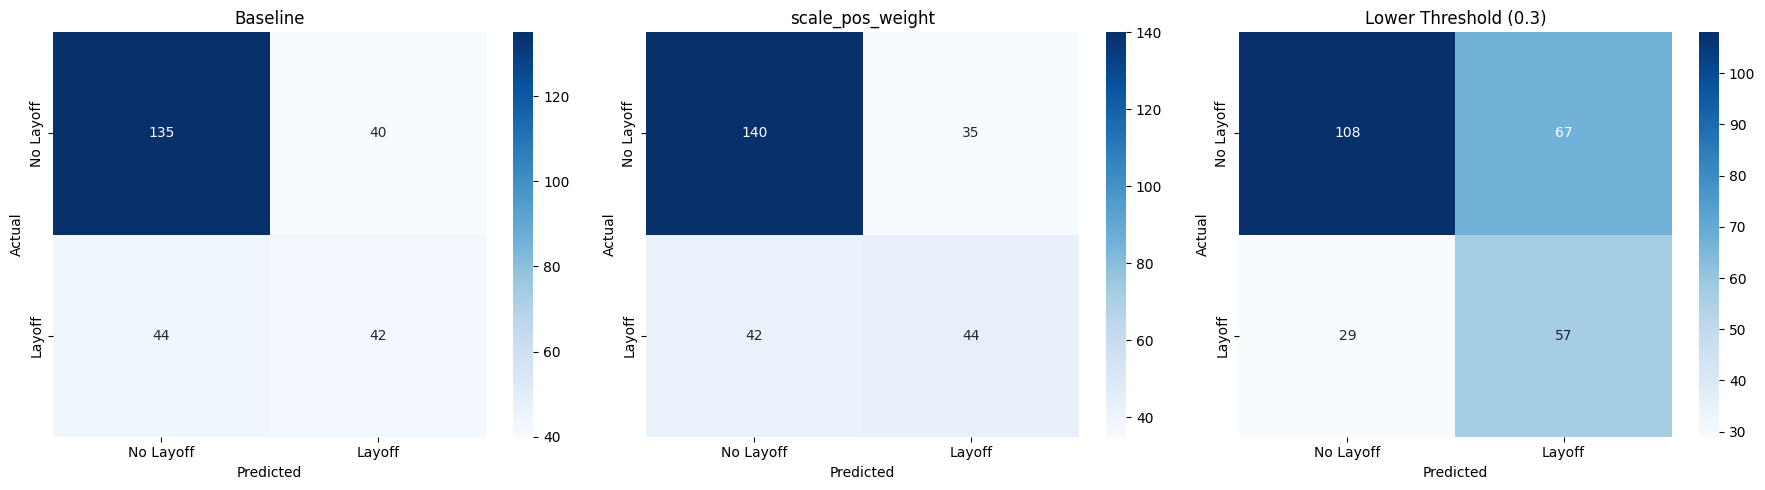

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, cm_data, title in zip(
    axes,
    [
        confusion_matrix(y_test, y_pred_base),
        confusion_matrix(y_test, y_pred_scaled),
        confusion_matrix(y_test, y_pred_thresh)
    ],
    ['Baseline', 'scale_pos_weight', 'Lower Threshold (0.3)']
):
    sns.heatmap(cm_data, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Layoff', 'Layoff'],
                yticklabels=['No Layoff', 'Layoff'])
    ax.set_title(title)
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.tight_layout()
plt.show()

In [63]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, cross_val_score

# Encode the full X before cross validation
X_encoded = X.copy()
oe_cv = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
X_encoded[['Industry', 'Stage', 'Country']] = oe_cv.fit_transform(
    X_encoded[['Industry', 'Stage', 'Country']]
)

print(X_encoded.dtypes)  # all should be float64 or int

# Now cross validate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scale = (y == 0).sum() / (y == 1).sum()

model_cv = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='logloss'
)

scores = cross_val_score(
    model_cv,
    X_encoded, y,
    cv=cv,
    scoring='f1'
)

print(f"Cross validated F1 scores: {scores}")
print(f"Mean F1: {scores.mean():.4f}")
print(f"Std: {scores.std():.4f}")

Industry          float64
Stage             float64
Country           float64
Funds_Raised      float64
Cash_Reserves     float64
Profit_Margin     float64
Revenue_Growth    float64
dtype: object
Cross validated F1 scores: [0.525      0.50322581 0.5380117  0.57317073 0.59259259]
Mean F1: 0.5464
Std: 0.0324


In [65]:
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Build pipeline for grid search
# GridSearchCV needs everything in one pipeline so SMOTE
# is applied correctly inside each fold
pipe = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        random_state=42,
        eval_metric='logloss',
        scale_pos_weight=scale
    ))
])

# Parameter grid to search
param_grid = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [3, 4, 6],
    'model__learning_rate': [0.01, 0.05, 0.1],
    'model__min_child_weight': [1, 3, 5],
    'model__subsample': [0.7, 0.8, 1.0],
}

# Grid search with cross validation
grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs= 1,  # use all CPU cores
    verbose=1
)

print("Running GridSearchCV... this will take 5-10 minutes")
grid_search.fit(X_encoded, y)

print(f"\nBest F1: {grid_search.best_score_:.4f}")
print(f"Best params: {grid_search.best_params_}")

Running GridSearchCV... this will take 5-10 minutes
Fitting 5 folds for each of 243 candidates, totalling 1215 fits

Best F1: 0.5908
Best params: {'model__learning_rate': 0.05, 'model__max_depth': 4, 'model__min_child_weight': 1, 'model__n_estimators': 300, 'model__subsample': 1.0}


── Tuned Model Performance ──
              precision    recall  f1-score   support

           0       0.94      0.78      0.85       175
           1       0.67      0.90      0.77        86

    accuracy                           0.82       261
   macro avg       0.80      0.84      0.81       261
weighted avg       0.85      0.82      0.82       261

ROC-AUC: 0.9242


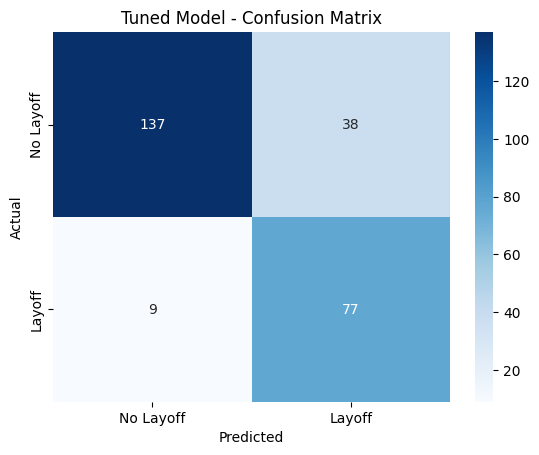

In [66]:
# Get best model from grid search
best_model = grid_search.best_estimator_

# Predict on test set
y_pred_best = best_model.predict(X_test)
y_prob_best = best_model.predict_proba(X_test)[:, 1]

print("── Tuned Model Performance ──")
print(classification_report(y_test, y_pred_best))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_best):.4f}")

# Confusion matrix
cm = confusion_matrix(y_test, y_pred_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Layoff', 'Layoff'],
            yticklabels=['No Layoff', 'Layoff'])
plt.title('Tuned Model - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [67]:
import pickle

with open("/Users/yashwanthkumar/Desktop/Desktop/ML project/early_layoff_warning/models/best_xgboost.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("/Users/yashwanthkumar/Desktop/Desktop/ML project/early_layoff_warning/models/encoder.pkl", "wb") as f:
    pickle.dump(oe_cv, f)

import json
best_params = {k.replace("model__", "") : v for k, v in grid_search.best_params_.items()}

with open("../models/best_params.json", "w") as f:
    json.dump(best_params, f, indent = 2)

print("Saved:")
print("  models/xgb_best_model.pkl")
print("  models/ordinal_encoder.pkl")
print("  models/best_params.json")

Saved:
  models/xgb_best_model.pkl
  models/ordinal_encoder.pkl
  models/best_params.json


In [69]:
from sklearn.metrics import f1_score

best_pipeline = ImbPipeline(steps=[
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        learning_rate=0.05,
        max_depth=4,
        min_child_weight=1,
        n_estimators=300,
        subsample=1.0,
        scale_pos_weight=scale,
        random_state=42,
        eval_metric='logloss'
    ))
])

best_pipeline.fit(X_train, y_train)

# Overwrite old saved model
with open('../models/xgb_best_model.pkl', 'wb') as f:
    pickle.dump(best_pipeline, f)

print("Model retrained and saved with XGBoost 3.2.0")

y_pred = best_pipeline.predict(X_test)
y_prob = best_pipeline.predict_proba(X_test)[:, 1]
print(f"F1: {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob):.4f}")

Model retrained and saved with XGBoost 3.2.0
F1: 0.5333
ROC-AUC: 0.6935


In [70]:
# Check what scale value we're getting now
print(f"scale_pos_weight: {scale:.4f}")

# Check class distribution
print(f"y_train label 0: {(y_train == 0).sum()}")
print(f"y_train label 1: {(y_train == 1).sum()}")

scale_pos_weight: 2.0256
y_train label 0: 696
y_train label 1: 344


In [71]:
import simfin as sf
import os
from dotenv import load_dotenv

load_dotenv()
sf.set_api_key(os.getenv('SIMFIN_API_KEY'))
sf.set_data_dir('../data/simfin/')

# Load income data
df_income = sf.load_income(variant='quarterly', market='us')
df_income = df_income.reset_index()

# Check latest available quarter for GOOGL
googl = df_income[df_income['Ticker'] == 'GOOG'].sort_values('Report Date', ascending=False)
print(googl[['Ticker', 'Report Date', 'Revenue', 'Net Income']].head(3))

Dataset "us-income-quarterly" on disk (1 days old).
- Loading from disk ... Done!
      Ticker Report Date       Revenue   Net Income
18483   GOOG  2025-03-31  9.023400e+10  34540000000
18482   GOOG  2024-12-31  9.646900e+10  26536000000
18481   GOOG  2024-09-30  8.826800e+10  26301000000
